In [2]:
import pandas as pd 

df = pd.read_csv("ventas_retail.csv")

df.groupby("ciudad")["monto"].sum()



ciudad
Buenos Aires    8855199
Córdoba         7198111
Mendoza         7706414
Rosario         7938539
Tucumán         7221605
Name: monto, dtype: int64

In [6]:
df.groupby(["ciudad", "categoria"])["monto"].sum()#suma

df.groupby("ciudad")["monto"].mean()#promedio

df.groupby("ciudad")["monto"].count()#contar

ciudad
Buenos Aires    109
Córdoba          95
Mendoza         112
Rosario          91
Tucumán          93
Name: monto, dtype: int64

In [7]:
df.groupby("vendedor")["monto"].agg(["sum", "mean", "count", "max"])

,sum,mean,count,max
vendedor,,,,
Ana Torres,5592010,79885.857143,70,149832
Carlos Vera,5114603,75214.750000,68,145272
Clara Díaz,5051539,77715.984615,65,148273
Lucía Paz,4423650,77607.894737,57,145180
Luis Gómez,5188342,76299.147059,68,149701
María López,4380650,70655.645161,62,146398
Pedro Ruiz,4105135,78944.903846,52,146706
Sofía Herrera,5063939,87309.293103,58,149539


In [7]:
df.groupby("ciudad").agg(
    total_ventas   = ("monto",    "sum"),
    ticket_promedio= ("monto",    "mean"),
    unidades_total = ("unidades", "sum"),
    descuento_max  = ("descuento","max"),
)

,total_ventas,ticket_promedio,unidades_total,descuento_max
ciudad,,,,
Buenos Aires,8855199,81240.357798,1089,0.2
Córdoba,7198111,75769.589474,931,0.2
Mendoza,7706414,68807.267857,1175,0.2
Rosario,7938539,87236.692308,946,0.2
Tucumán,7221605,77651.666667,880,0.2


In [ ]:
resultado = df.groupby("ciudad")["monto"].sum()
print(type(resultado.index))   # Index — el índice es la ciudad

resultado_plano = resultado.reset_index()#cambiar de lugar el indice y que sea una columna mas
print(resultado_plano)

<class 'pandas.Index'>
         ciudad    monto
0  Buenos Aires  8855199
1       Córdoba  7198111
2       Mendoza  7706414
3       Rosario  7938539
4       Tucumán  7221605


In [12]:
tabla = df.pivot_table(
    values  = "monto",
    index   = "ciudad",
    columns = "categoria",
    aggfunc = "sum",
)

tabla

categoria,Alimentos,Deportes,Electrónica,Hogar,Ropa
ciudad,,,,,
Buenos Aires,1876997,1372041,1951331,1607118,2047712
Córdoba,1787767,1778075,1286509,1292147,1053613
Mendoza,891215,1718730,1472067,1533021,2091381
Rosario,1715244,1676528,1526021,1783981,1236765
Tucumán,2595971,1047502,1445364,1324889,807879


In [16]:
tabla_multiple = df.pivot_table(
    values  = "monto",
    index   = "ciudad",
    columns = "trimestre",
    aggfunc = ["sum", "mean"],
)

tabla_multiple

sum                                     mean                \
trimestre          Q1       Q2       Q3       Q4            Q1            Q2   
ciudad                                                                         
Buenos Aires  2556390  2735824  1607655  1955330  75187.941176  88252.387097   
Córdoba       1632413  1596225  1932245  2037228  77733.952381  69401.086957   
Mendoza       2500488  1617051  1907793  1681082  73543.764706  64682.040000   
Rosario       1957784  2212611  2461971  1306173  81574.333333  96200.478261   
Tucumán       1536296  2079097  1103564  2502648  73156.952381  77003.592593   

                                          
trimestre               Q3            Q4  
ciudad                                    
Buenos Aires  76555.000000  85014.347826  
Córdoba       80510.208333  75452.888889  
Mendoza       70659.000000  64657.000000  
Rosario       82065.700000  93298.071429  
Tucumán       91963.666667  75837.818182

In [17]:
# groupby con dos columnas → MultiIndex
por_ciudad_trim = df.groupby(["ciudad", "trimestre"])["monto"].sum()
print(por_ciudad_trim)

ciudad        trimestre
Buenos Aires  Q1           2556390
              Q2           2735824
              Q3           1607655
              Q4           1955330
Córdoba       Q1           1632413
              Q2           1596225
              Q3           1932245
              Q4           2037228
Mendoza       Q1           2500488
              Q2           1617051
              Q3           1907793
              Q4           1681082
Rosario       Q1           1957784
              Q2           2212611
              Q3           2461971
              Q4           1306173
Tucumán       Q1           1536296
              Q2           2079097
              Q3           1103564
              Q4           2502648
Name: monto, dtype: int64


In [19]:
# unstack() convierte el trimestre (nivel interno) en columnas
tabla_unstacked = por_ciudad_trim.unstack()
tabla_unstacked


trimestre,Q1,Q2,Q3,Q4
ciudad,,,,
Buenos Aires,2556390,2735824,1607655,1955330
Córdoba,1632413,1596225,1932245,2037228
Mendoza,2500488,1617051,1907793,1681082
Rosario,1957784,2212611,2461971,1306173
Tucumán,1536296,2079097,1103564,2502648


In [20]:
pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


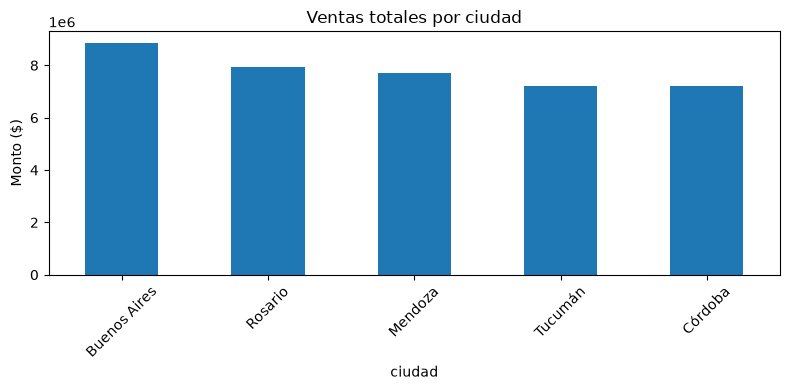

In [21]:
import matplotlib.pyplot as plt

# Ventas totales por ciudad — gráfico de barras
totales_ciudad = df.groupby("ciudad")["monto"].sum().sort_values(ascending=False)

totales_ciudad.plot(kind="bar", figsize=(8, 4), title="Ventas totales por ciudad")
plt.ylabel("Monto ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

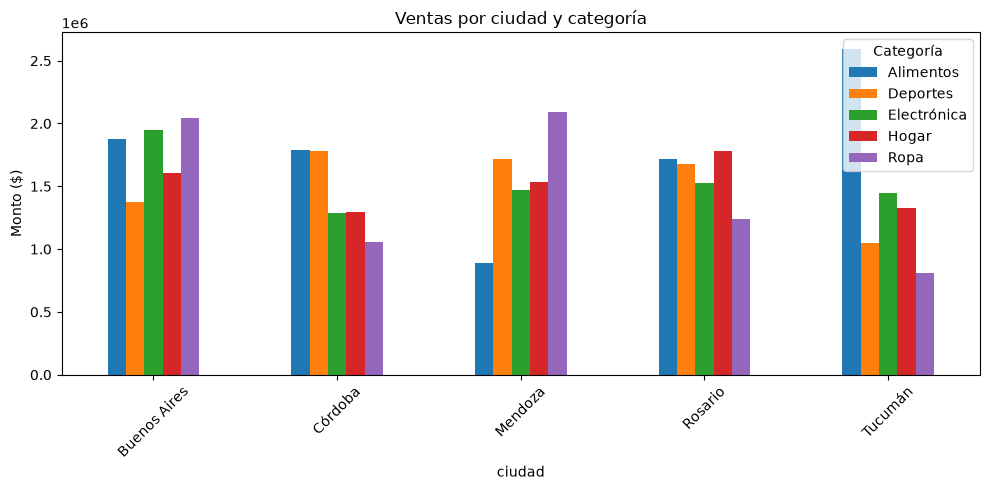

In [22]:
tabla.plot(kind="bar", figsize=(10, 5), title="Ventas por ciudad y categoría")
plt.ylabel("Monto ($)")
plt.xticks(rotation=45)
plt.legend(title="Categoría")
plt.tight_layout()
plt.show()

=== Ciudad con más ventas ===
ciudad
Buenos Aires    8855199
Rosario         7938539
Mendoza         7706414
Tucumán         7221605
Córdoba         7198111
Name: monto, dtype: int64

Ganadora: Buenos Aires ($8,855,199)

=== Ingresos por categoría y trimestre ===
trimestre         Q1       Q2       Q3       Q4
categoria                                      
Alimentos    2018617  2420102  1798483  2629992
Deportes     2331622  1667151  2095008  1499095
Electrónica  2180347  2155875  1656060  1689010
Hogar        1420609  2045656  1688955  2385936
Ropa         2232176  1952024  1774722  1278428

=== Ticket promedio por vendedor ===
vendedor
Sofía Herrera    87309.0
Ana Torres       79886.0
Pedro Ruiz       78945.0
Clara Díaz       77716.0
Lucía Paz        77608.0
Luis Gómez       76299.0
Carlos Vera      75215.0
María López      70656.0
Name: monto, dtype: float64

Mejor ticket promedio: Sofía Herrera ($87,309)


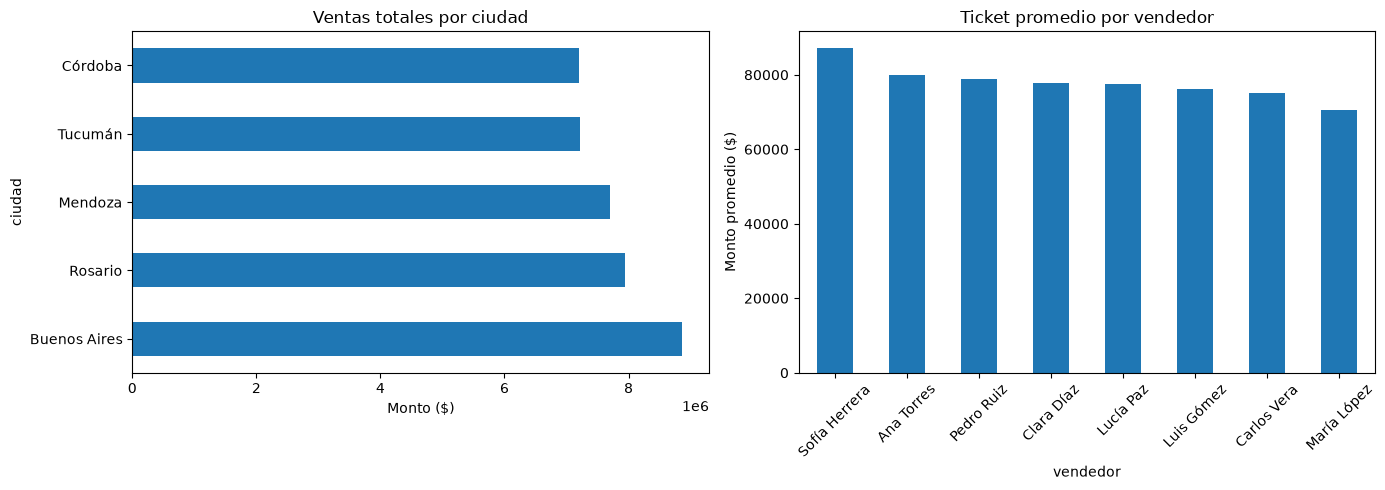

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ventas_retail.csv")

# ¿Qué ciudad vende más?
print("=== Ciudad con más ventas ===")
por_ciudad = df.groupby("ciudad")["monto"].sum().sort_values(ascending=False)
print(por_ciudad)
print(f"\nGanadora: {por_ciudad.index[0]} (${por_ciudad.iloc[0]:,.0f})")

# ¿Qué categoría genera más ingresos por trimestre?
print("\n=== Ingresos por categoría y trimestre ===")
tabla_trim = df.pivot_table(
    values    = "monto",
    index     = "categoria",
    columns   = "trimestre",
    aggfunc   = "sum",
    fill_value= 0,
)
print(tabla_trim)

# ¿Qué vendedor tiene el ticket promedio más alto?
print("\n=== Ticket promedio por vendedor ===")
ticket = df.groupby("vendedor")["monto"].mean().sort_values(ascending=False)
print(ticket.round(0))
print(f"\nMejor ticket promedio: {ticket.index[0]} (${ticket.iloc[0]:,.0f})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_ciudad.plot(kind="barh", ax=axes[0], title="Ventas totales por ciudad")
axes[0].set_xlabel("Monto ($)")

ticket.plot(kind="bar", ax=axes[1], title="Ticket promedio por vendedor")
axes[1].set_ylabel("Monto promedio ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()